In [1]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
test_sample = "7_0/"
if os.path.isdir(test_sample):
    os.system("rm -r {}".format(test_sample))
os.system("cp -r init/{} {}".format(test_sample,test_sample))
dir = test_sample
file = "minimized.txt"

alpha = 0.1
tissue = PeriodicTissue.from_config(dir,file)
training_instance = Patterns.periodic_tissue(tissue)
training_instance.set_tolerance(1e-6)
training_instance.set_random_target_cells()
# training_instance.set_central_target_cells()

for cellID in training_instance._target_cell_to_stress:
    initial_stress = stress.calculate_max_shear_stress(training_instance._config, cellID)
    training_instance._target_cell_to_stress[cellID] = (1+alpha) * initial_stress
    print("Initial stress for cell {}: {}".format(cellID, initial_stress))
print(training_instance._target_cell_to_stress)
training_instance.run()



Initial stress for cell 211: 0.19529062096483063
{211: np.float64(0.21481968306131372)}
Initial Cost: 3.81e-04




Starting iteration: 0




Number of modifiable cells: 343


-------------------------------------
Step 1: Evaluate and store the current (free state) areas of hidden (non-target) cells


-------------------------------------
Step 2: CLAMPING
Clamping iteration 0
Cell: 211, Final Target Stress: 0.21481968306131372 Temporary Target Stress: 0.2567719523618258, Current stress: 0.19529062096483063, s0: 5.0
Initialization start ...
Number of vertices: 2047
Maximum vertex ID: 6393
Number of edges: 4094
Maximum edge ID: 17842
Number of polygons: 2390
Maximum polygon ID: 3364
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2390/2390
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
Average s0: 5
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 7 7 7 periodic boundary condition: 1 1 1


Initial F_rms: 0.00968914

Starting FIRE minimizat

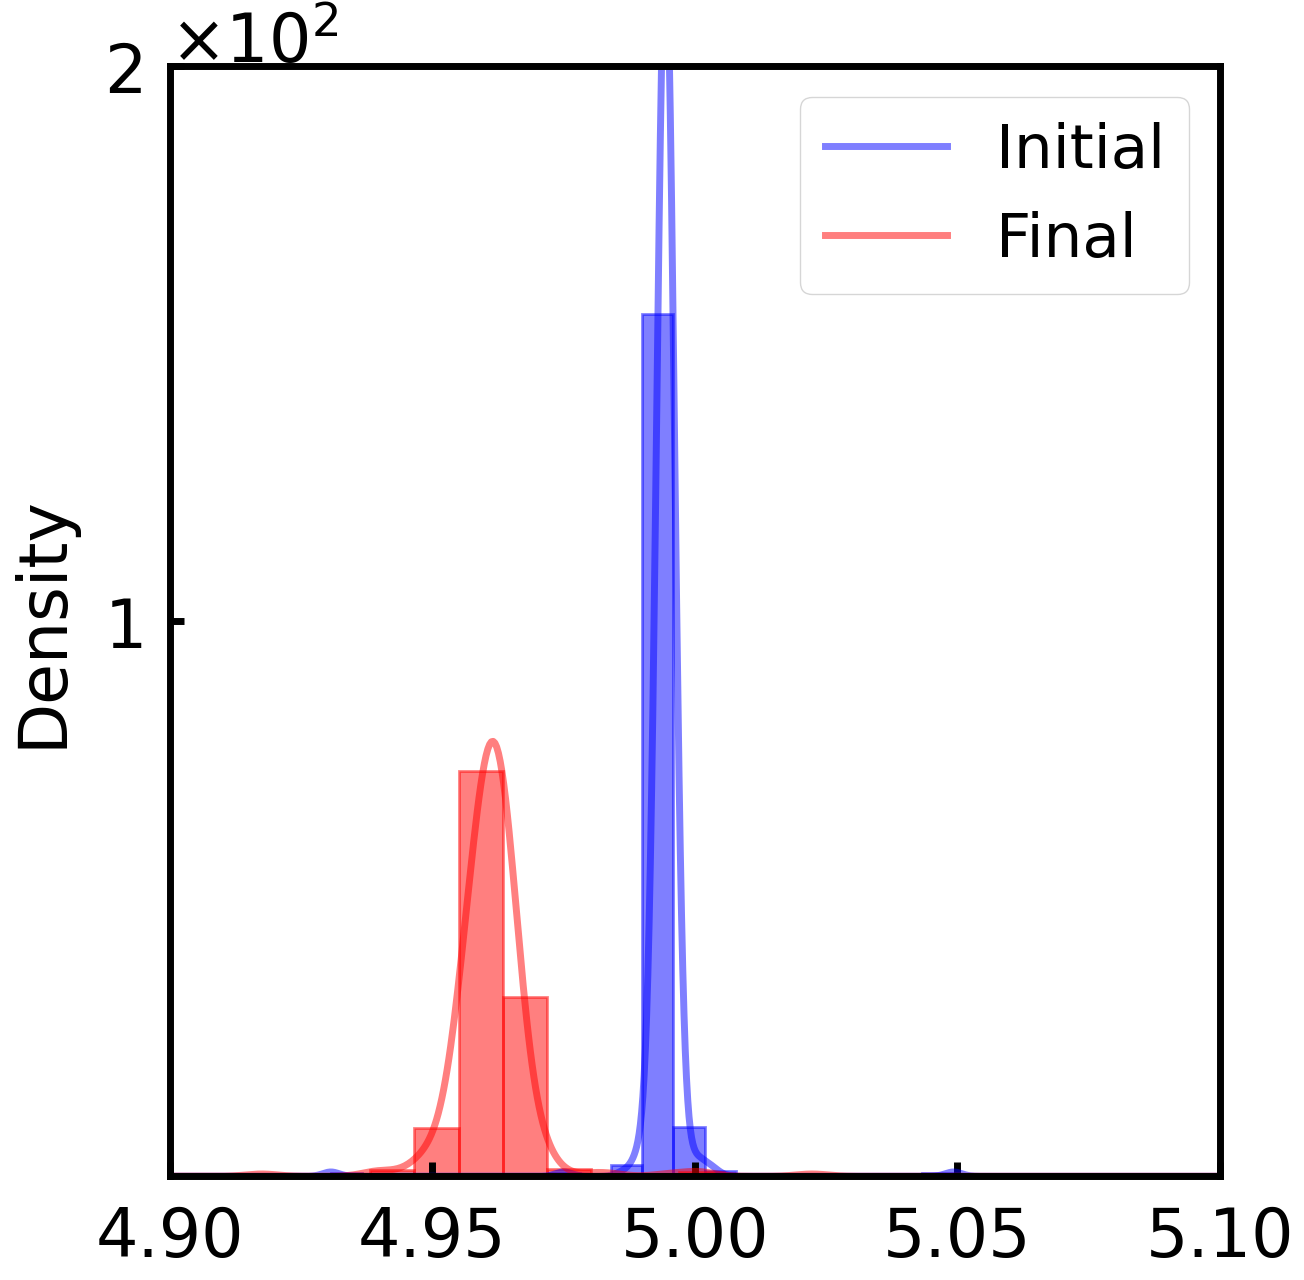

In [ ]:
import pandas as pd
from toolbox import manuscriptPlots

df = pd.read_csv("7_0_new_toolbox_success/cellParameters.15.input", sep=" ",header=None)

iter_to_labels = {0:"Initial", 15:"Trained"}
iter_to_colors = {0:"blue", 15:"red"}
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,200)
plotter.set_xlim(4.9,5.1)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel("s0")
plotter.set_xticks([4.9+0.05*i for i in range(50)])
plotter.set_yticks([100*i for i in range(1,100)])
plotter.set_yScaled()
plotter.initialize_figure()
for i, label in iter_to_labels.items():
    df = pd.read_csv("7_0_new_toolbox_success/cellParameters.{}.input".format(i), sep=" ",header=None)


    plotter.histogram_from_dataframe(df[2],color=iter_to_colors[i], bins=20, label = label)
plotter.save_fig("7_0_new_toolbox_success/s0_histogram.jpg")
